In [4]:
from typing import Any, Callable

import numpy as np
from langchain_core.tools import tool
import io
import base64
from PIL import Image

# ---------------------------------------------------------------------------
# Camera initialisation — two singletons: base (RealSense) + wrist (OpenCV)
#
# Priority for each camera:
#   1. ZMQ camera server (localhost:5555) — required when VLA robot_client is
#      running, because that process owns the hardware exclusively.
#   2. Direct hardware — fallback for standalone testing (no VLA running).
# ---------------------------------------------------------------------------

_camera_base = None
_camera_wrist = None
_camera_base_error: str = ""
_camera_wrist_error: str = ""

_CAMERA_SERVER_HOST = "localhost"
_CAMERA_SERVER_PORT = 5555
_WRIST_OPENCV_PATH = "/dev/video10"
_WRIST_OPENCV_INDEX = 0           # numeric fallback if path fails


def _init_camera() -> None:
    """Open both cameras (lazy, called on first observation)."""
    _init_base_camera()
    _init_wrist_camera()


def _try_zmq_camera(camera_name: str):
    """Connect to a named camera on the ZMQ server. Returns camera or None."""
    try:
        from lerobot.cameras.zmq.camera_zmq import ZMQCamera
        from lerobot.cameras.zmq.configuration_zmq import ZMQCameraConfig

        config = ZMQCameraConfig(
            server_address=_CAMERA_SERVER_HOST,
            port=_CAMERA_SERVER_PORT,
            camera_name=camera_name,
            timeout_ms=1000,
            warmup_s=1,
        )
        cam = ZMQCamera(config)
        cam.connect(warmup=True)
        print(f"ZMQ '{camera_name}' connected at {_CAMERA_SERVER_HOST}:{_CAMERA_SERVER_PORT}.")
        return cam
    except Exception as exc:
        print(f"ZMQ '{camera_name}' not reachable: {exc}")
        return None


def _init_base_camera() -> None:
    global _camera_base, _camera_base_error
    if _camera_base is not None:
        return

    cam = _try_zmq_camera("base")
    if cam:
        _camera_base = cam
        return

    # Direct RealSense fallback
    try:
        from lerobot.cameras.realsense.camera_realsense import RealSenseCamera
        from lerobot.cameras.realsense.configuration_realsense import RealSenseCameraConfig

        serial = _find_first_realsense_serial()
        config = RealSenseCameraConfig(serial_number_or_name=serial, fps=15, width=640, height=480)
        cam = RealSenseCamera(config)
        cam.connect(warmup=True)
        _camera_base = cam
        print("Base: RealSense opened directly.")
    except Exception as exc:
        _camera_base_error = f"Base camera unavailable: {exc}"
        print(_camera_base_error)


def _init_wrist_camera() -> None:
    global _camera_wrist, _camera_wrist_error
    if _camera_wrist is not None:
        return

    cam = _try_zmq_camera("wrist")
    if cam:
        _camera_wrist = cam
        return

    # Direct OpenCV fallback
    try:
        from lerobot.cameras.opencv.camera_opencv import OpenCVCamera
        from lerobot.cameras.opencv.configuration_opencv import OpenCVCameraConfig

        config = OpenCVCameraConfig(index_or_path=_WRIST_OPENCV_PATH, fps=30, width=640, height=480)
        cam = OpenCVCamera(config)
        cam.connect(warmup=True)
        _camera_wrist = cam
        print(f"Wrist: OpenCV opened at {_WRIST_OPENCV_PATH}.")
    except Exception as exc:
        _camera_wrist_error = f"Wrist camera unavailable: {exc}"
        print(_camera_wrist_error)


def _find_first_realsense_serial() -> str:
    from lerobot.cameras.realsense.camera_realsense import RealSenseCamera
    cameras = RealSenseCamera.find_cameras()
    if not cameras:
        raise RuntimeError("No RealSense cameras found.")
    return str(cameras[0]["id"])


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _frame_to_base64(frame_rgb: np.ndarray) -> str:
    from PIL import Image as PILImage
    import io, base64
    img = PILImage.fromarray(frame_rgb)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()


def _run_detection(frame_rgb: np.ndarray, target_object: str) -> list[dict[str, Any]]:
    """
    Object detection placeholder — replace with YOLO World when ready.

    Expected return format:
        [{"label": str, "id": str, "x": float, "y": float, "z": float,
          "confidence": float, "bbox_px": [x1, y1, x2, y2]}, ...]
    """
    h, w = frame_rgb.shape[:2]
    return [
        {"label": target_object, "id": f"{target_object}_0",
         "x": 0.12, "y": -0.05, "z": 0.30, "confidence": 0.93,
         "bbox_px": [w//4, h//4, w//2, h//2]},
        {"label": target_object, "id": f"{target_object}_1",
         "x": 0.22, "y":  0.03, "z": 0.29, "confidence": 0.88,
         "bbox_px": [w//2, h//3, 3*w//4, 2*h//3]},
    ]


In [5]:
# ---------------------------------------------------------------------------
# Capability implementations
# ---------------------------------------------------------------------------

def _get_observation(target_object: str = "screw", **kwargs: Any) -> dict[str, Any]:
    """
    Capture base + wrist frames, run detection (stubbed), and return results.

    Returned dict includes:
      frame_b64       — base64 PNG from the base (RealSense) camera
      wrist_frame_b64 — base64 PNG from the wrist camera
      detected        — list of detected objects with 3-D positions (from base)
      camera_info     — which backends were used
    """
    _init_camera()

    base_b64: str = ""
    wrist_b64: str = ""
    detected: list[dict[str, Any]] = []
    errors: list[str] = []

    # --- Base camera ---
    if _camera_base is None:
        errors.append(_camera_base_error or "Base camera not available.")
    else:
        try:
            frame_base = _camera_base.read()
            base_b64 = _frame_to_base64(frame_base)
            detected = _run_detection(frame_base, target_object)
        except Exception as exc:
            errors.append(f"Base capture failed: {exc}")
            frame_base = None

    # --- Wrist camera ---
    if _camera_wrist is None:
        errors.append(_camera_wrist_error or "Wrist camera not available.")
    else:
        try:
            frame_wrist = _camera_wrist.read()
            wrist_b64 = _frame_to_base64(frame_wrist)
        except Exception as exc:
            errors.append(f"Wrist capture failed: {exc}")

    camera_info = {
        "base":  type(_camera_base).__name__  if _camera_base  else "none",
        "wrist": type(_camera_wrist).__name__ if _camera_wrist else "none",
    }

    return {
        "capability": "get_observation",
        "target": target_object,
        "detected": detected,
        "count": len(detected),
        "frame_b64": base_b64,
        "wrist_frame_b64": wrist_b64,
        "camera_info": camera_info,
        "error": "; ".join(errors),
        "note": (
            "Detection results are STUB placeholders. "
            "Wire _run_detection() to YOLO World when model is ready."
        ),
    }


ZMQ 'base' connected at localhost:5555.
ZMQ 'wrist' connected at localhost:5555.
Base camera:  ZMQCamera
Wrist camera: ZMQCamera
Detections:   2


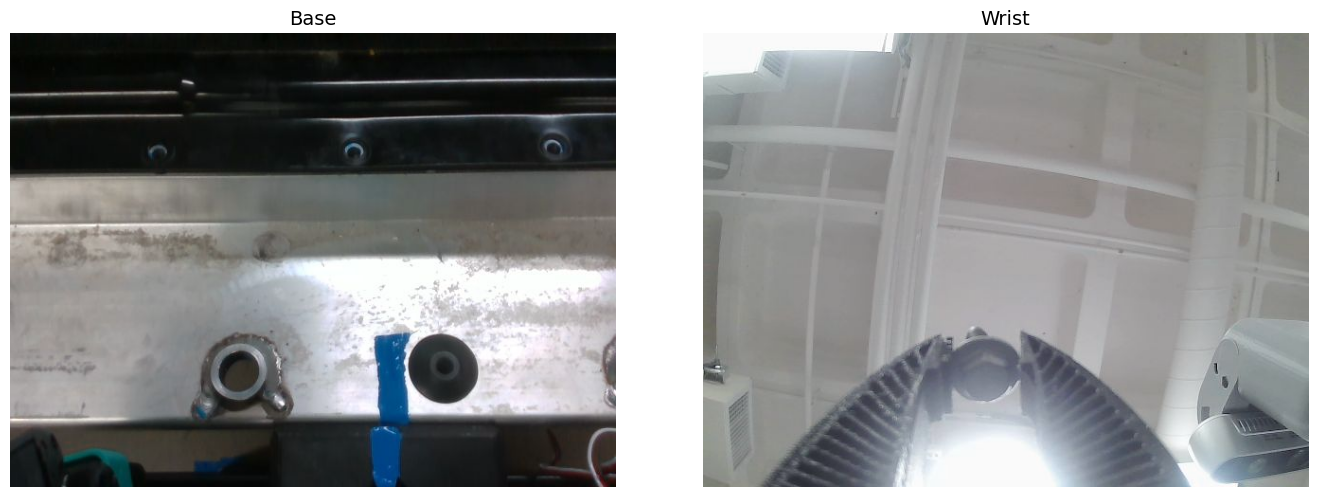

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from base64 import b64decode
from PIL import Image as PILImage
import io

obs = _get_observation(target_object="screw")

if obs["error"]:
    print(f"Warning: {obs['error']}")

print(f"Base camera:  {obs['camera_info']['base']}")
print(f"Wrist camera: {obs['camera_info']['wrist']}")
print(f"Detections:   {obs['count']}")

# Decode whichever frames came back
frames = {}
if obs["frame_b64"]:
    frames["Base"] = PILImage.open(io.BytesIO(b64decode(obs["frame_b64"])))
if obs["wrist_frame_b64"]:
    frames["Wrist"] = PILImage.open(io.BytesIO(b64decode(obs["wrist_frame_b64"])))

if frames:
    fig, axes = plt.subplots(1, len(frames), figsize=(7 * len(frames), 5))
    if len(frames) == 1:
        axes = [axes]
    for ax, (label, img) in zip(axes, frames.items()):
        ax.imshow(img)
        ax.set_title(label, fontsize=14)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No frames captured.")
